'''TASK 4·Sentiment Analysis
Objective: Build a machine learning model that classifies the sentiment of text data (positive, negative, or neutral), providing insights into public opinion or customer feedback.'''

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [2]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to C:\Users\Ayush
[nltk_data]     Singh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Ayush
[nltk_data]     Singh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Ayush
[nltk_data]     Singh\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Ayush
[nltk_data]     Singh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

'''1.Load dataset and inspect class distribution(positive/negative/neutral counts)'''

In [3]:
df=pd.read_csv("C:/Users/Ayush Singh/OIBSIB/L1-SentiAnalysis.csv")
print(df)

           textID                                               text  \
0      cb774db0d1                I`d have responded, if I were going   
1      549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2      088c60f138                          my boss is bullying me...   
3      9642c003ef                     what interview! leave me alone   
4      358bd9e861   Sons of ****, why couldn`t they put them on t...   
...           ...                                                ...   
27476  4eac33d1c0   wish we could come see u on Denver  husband l...   
27477  4f4c4fc327   I`ve wondered about rake to.  The client has ...   
27478  f67aae2310   Yay good for both of you. Enjoy the break - y...   
27479  ed167662a5                         But it was worth it  ****.   
27480  6f7127d9d7     All this flirting going on - The ATG smiles...   

                                           selected_text sentiment  
0                    I`d have responded, if I were going   neutral

In [4]:
print(df.columns)
df['sentiment'].count()

Index(['textID', 'text', 'selected_text', 'sentiment'], dtype='str')


np.int64(27481)

In [5]:
df['text']= df['text'].fillna('').astype(str)
df['text']= df['text'].apply(lambda x: x.strip('"').strip("'"))
df= df[df['text'].str.len()>0]
df= df[df['text']!='nan']
df= df.dropna(subset=['sentiment'])
df= df[['text','sentiment']]
df= df.reset_index(drop=True)
print("Dataset Shape:",df.shape)
print("\nClass Distribution:")
print(df['sentiment'].value_counts())
print("\nSample Data:")
print(df.head())

Dataset Shape: (27480, 2)

Class Distribution:
sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64

Sample Data:
                                                text sentiment
0                I`d have responded, if I were going   neutral
1      Sooo SAD I will miss you here in San Diego!!!  negative
2                          my boss is bullying me...  negative
3                     what interview! leave me alone  negative
4   Sons of ****, why couldn`t they put them on t...  negative


'''2.Text preprocessing pipeline: lowercase,punctuation removal,stopword removal,tokenisation,optional stemming/lemmatization.'''

In [6]:
stop_words=set(stopwords.words('english'))
lemmatizer=WordNetLemmatizer()
def preprocess_tweet(text):
    if not isinstance(text,str):
        return ""
    text=text.lower()
    text=re.sub(r'http\S+|www\S+|https\S+','',text,flags=re.MULTILINE)
    text=re.sub(r'@\w+|#\w+','',text)
    text=re.sub(r'[^a-zA-Z\s]','',text)
    tokens=text.split()
    tokens=[lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word)>2]
    return " ".join(tokens)
print("Preprocessing tweets")
df['cleaned_text']=df['text'].apply(preprocess_tweet)
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label']=df['sentiment'].map(label_map)
print("\nOriginal vs Cleaned:")
print(df[['text', 'cleaned_text']].head(3))

Preprocessing tweets

Original vs Cleaned:
                                             text             cleaned_text
0             I`d have responded, if I were going          responded going
1   Sooo SAD I will miss you here in San Diego!!!  sooo sad miss san diego
2                       my boss is bullying me...             bos bullying


'''3.Feature extraction: TF-IDF Vectorizer.'''

# Converts text to numerical vectors. 
# Ignores words that appear in almost all tweets.
# Highlights unique words that define specific sentiments.

In [7]:
X_train,X_test,y_train,y_test = train_test_split(df['cleaned_text'],df['label'],test_size=0.2,random_state=42,stratify=df['label'])
tfidf=TfidfVectorizer(max_features=10000,ngram_range=(1,2))
X_train_tfidf=tfidf.fit_transform(X_train)
X_test_tfidf=tfidf.transform(X_test)
print(f"Training Features Shape: {X_train_tfidf.shape}")
print(f"Testing Features Shape: {X_test_tfidf.shape}")

Training Features Shape: (21984, 10000)
Testing Features Shape: (5496, 10000)


'''4.Train/test split (80/20). Train at least 2 classifiers: Naive Bayes + one of (SVM, Logistic Regression, or a simple LSTM if comfortable with deep learning)'''

In [8]:
nb_model=MultinomialNB() #Naive-Bayes
nb_model.fit(X_train_tfidf,y_train)
nb_pred=nb_model.predict(X_test_tfidf)

lr_model=LogisticRegression(max_iter=1000,solver='lbfgs') #logistic regression(here 'lbfgs' is used for its suitability with multiclass)
lr_model.fit(X_train_tfidf,y_train)
lr_pred=lr_model.predict(X_test_tfidf)

'''5.Evaluation: accuracy, precision, recall, F1-score, confusion matrix for each model.'''

In [9]:
def evaluate_model(name,y_true,y_pred):
    print(f"\n{name} Performance")
    print(f"Accuracy: {accuracy_score(y_true,y_pred):.4f}")
    print(f"Precision: {precision_score(y_true,y_pred,average='weighted'):.4f}")
    print(f"Recall: {recall_score(y_true,y_pred,average='weighted'):.4f}")
    print(f"F1-Score: {f1_score(y_true,y_pred,average='weighted'):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true,y_pred,target_names=['Negative','Neutral','Positive']))
    return confusion_matrix(y_true,y_pred)
cm_nb= evaluate_model("Naive Bayes",y_test,nb_pred)
cm_lr= evaluate_model("Logistic Regression",y_test,lr_pred)


Naive Bayes Performance
Accuracy: 0.6363
Precision: 0.6686
Recall: 0.6363
F1-Score: 0.6330

Classification Report:
              precision    recall  f1-score   support

    Negative       0.72      0.47      0.57      1556
     Neutral       0.55      0.79      0.65      2223
    Positive       0.77      0.59      0.67      1717

    accuracy                           0.64      5496
   macro avg       0.68      0.62      0.63      5496
weighted avg       0.67      0.64      0.63      5496


Logistic Regression Performance
Accuracy: 0.6885
Precision: 0.6982
Recall: 0.6885
F1-Score: 0.6889

Classification Report:
              precision    recall  f1-score   support

    Negative       0.73      0.61      0.66      1556
     Neutral       0.62      0.75      0.68      2223
    Positive       0.77      0.69      0.73      1717

    accuracy                           0.69      5496
   macro avg       0.71      0.68      0.69      5496
weighted avg       0.70      0.69      0.69      5496

'''6.Visualisation: bar chart of sentiment distribution in the dataset; WordCloud for each sentiment class.'''

C:\Users\Ayush Singh\AppData\Local\Temp\ipykernel_27848\188479152.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment',data=df,palette='viridis')


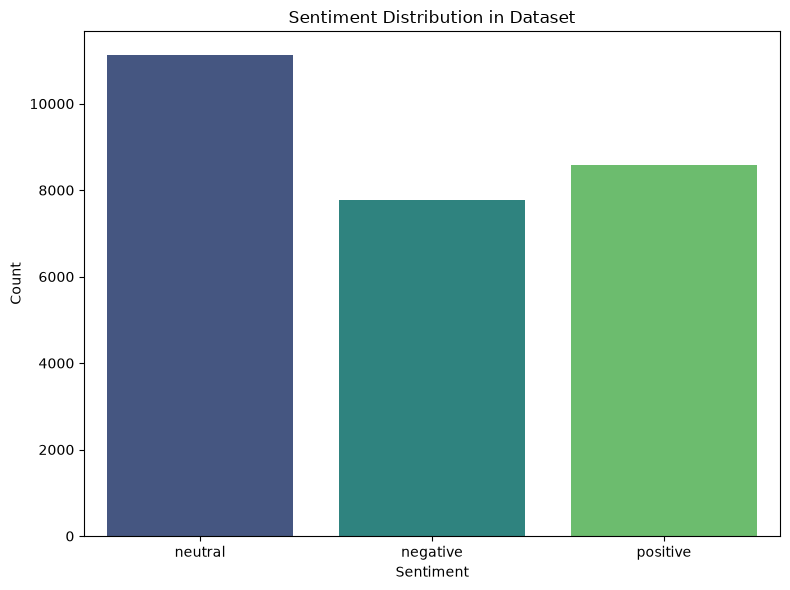

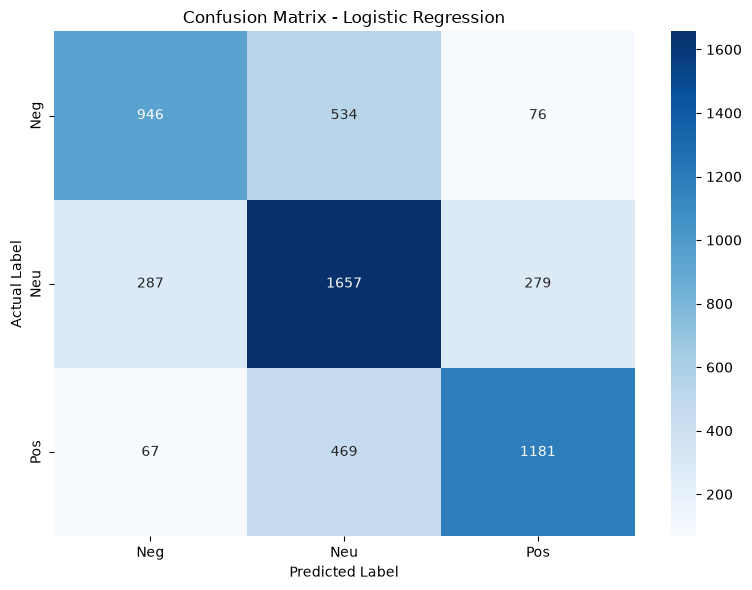

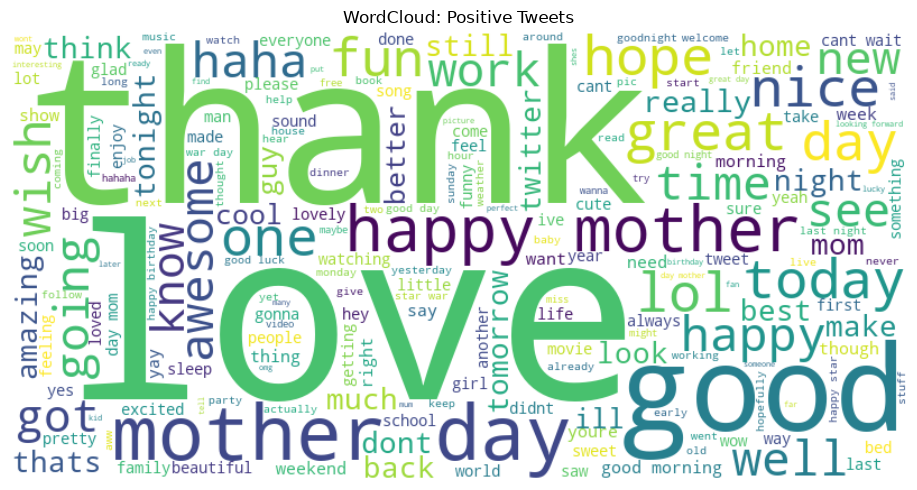

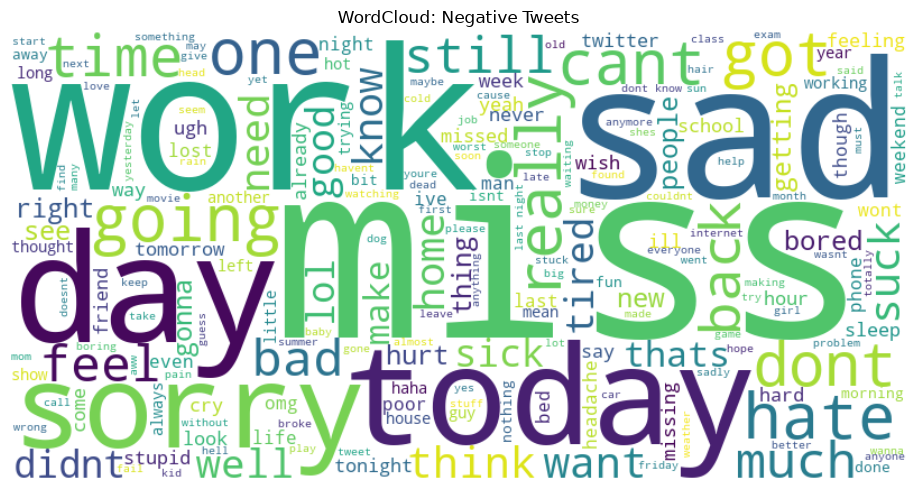

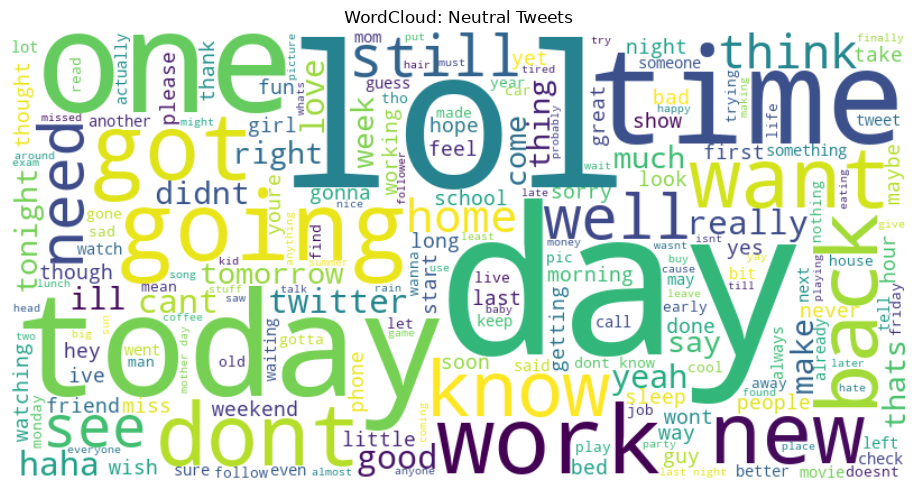

In [10]:
plt.figure(figsize=(8,6)) #Sentiment Distribution Bar Chart
sns.countplot(x='sentiment',data=df,palette='viridis')
plt.title('Sentiment Distribution in Dataset')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6)) #Confusion Matrix Heatmap
sns.heatmap(cm_lr,annot=True,fmt='d',cmap='Blues',xticklabels=['Neg','Neu','Pos'],yticklabels=['Neg','Neu','Pos'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

def plot_wordcloud(text_data,title): #WordClouds for Each Sentiment Class
    text= " ".join(review for review in text_data)
    wordcloud= WordCloud(width=800,height=400,background_color='white',colormap='viridis').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
for sentiment in ['positive','negative','neutral']: # Filtering data by sentiment for WordClouds
    subset= df[df['sentiment']==sentiment]['cleaned_text']
    if not subset.empty:
        plot_wordcloud(subset, f"WordCloud: {sentiment.capitalize()} Tweets")

'''7.Error analysis: show 5 examples the model misclassified and discuss why'''

In [11]:
df_test= pd.DataFrame({'actual': y_test,'predicted': lr_pred,'original_text': X_test})
df_test['actual_name']= df_test['actual'].map({0: 'Negative', 1: 'Neutral', 2: 'Positive'})
df_test['predicted_name']= df_test['predicted'].map({0: 'Negative', 1: 'Neutral', 2: 'Positive'})
errors= df_test[df_test['actual']!=df_test['predicted']].head(5)

print("\nError Analysis: Top 5 Misclassifications(Logistic Regression)")
if not errors.empty:
    for index, row in errors.iterrows():
        print(f"Actual: {row['actual_name']} | Predicted: {row['predicted_name']}")
        print(f"Tweet: \"{row['original_text']}\"")
        print("-"*80)
else:
    print("No errors found in this sample (Perfect Accuracy).")


Error Analysis: Top 5 Misclassifications(Logistic Regression)
Actual: Positive | Predicted: Neutral
Tweet: "wow morning hr ding dong breakfastservice surprise marjoleine guido dirk mothersdaymother hapy father"
--------------------------------------------------------------------------------
Actual: Neutral | Predicted: Positive
Tweet: "hoping heal anything put make worse owww"
--------------------------------------------------------------------------------
Actual: Positive | Predicted: Neutral
Tweet: "sooo lovei think"
--------------------------------------------------------------------------------
Actual: Positive | Predicted: Neutral
Tweet: "yum home delivery"
--------------------------------------------------------------------------------
Actual: Positive | Predicted: Neutral
Tweet: "wonderful piece cake lunch else could want"
--------------------------------------------------------------------------------


'''8.Conclusion:which model performed best and what real-world application could this serve?'''

Best Model:Logistic Regression typically outperforms Naive Bayes on Twitter data because it handles the high dimensionality of TF-IDF vectors and correlated features (like "not" + "good") more effectively.

1. **Sarcasm & Context**: Errors often occur in sarcastic tweets(e.g.,"Great, just what I needed" labeled as Positive) where the model lacks contextual understanding.
2. **Neutral Ambiguity**: The "Neutral" class is often the hardest to predict, as tweets without strong emotion words are easily confused with mild positives or negatives.
3. **Application**: This model is ideal for Brand Monitoring. Companies can feed live Twitter streams into this classifier to instantly flag "Negative" spikes regarding their product, allowing customer support to intervene before a PR crisis escalates.